# Experiment 5.3.2.2 — RSNN hidden-state capacity sweep

Analysis-only notebook for the finalized Exp5.3.2.2 width sweep. It never trains models, refits probes, or submits jobs.

Sections: Capacity curve, Generalization, Temporal quality, History contribution, SNN-native accessibility, Activity utilization, Effective state dimension, and hierarchical winner selection.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "AGENTS.md").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root")


repo_root = find_repo_root()
artifact_root = repo_root / "notebooks" / "artifacts" / "experiment_5_3_2_2_when_width_sweep" / "rsnn_when_width_v1"

manifest = json.loads((artifact_root / "manifest.json").read_text(encoding="utf-8"))
runs = pd.read_csv(artifact_root / "runs.csv")
histories = pd.read_csv(artifact_root / "histories.csv")
probe_runs = pd.read_csv(artifact_root / "probe_runs.csv")
ablation_runs = pd.read_csv(artifact_root / "ablation_runs.csv")
history_gain_runs = pd.read_csv(artifact_root / "history_gain_runs.csv")
activity_runs = pd.read_csv(artifact_root / "activity_runs.csv")
representation_runs = pd.read_csv(artifact_root / "representation_runs.csv")
baseline_runs = pd.read_csv(artifact_root / "baseline_runs.csv")
local_reference = pd.read_csv(artifact_root / "local_reference.csv")

assert manifest["expected_runs"] == 25
assert len(runs) == 25
assert set(runs["hidden_width"]) == {16, 32, 64, 128, 256}
assert runs.groupby("hidden_width")["seed"].nunique().eq(5).all()
manifest


{'activity_thresholds': {'dead_neuron_fraction': 'FR < 0.0001',
  'highly_active_neuron_fraction': 'FR > 0.1 spikes/timestep'},
 'aggregation_policy': 'finalizer requires all 25 evaluations, all 25 histories, all five baseline artifacts, and only aggregates existing artifacts',
 'baseline_reuse': 'identity-validated Exp5.3.2.1 baseline artifacts; no refitting',
 'baselines': ['what_only', 'elapsed_time_only'],
 'causality_contract': 'T_i is used only to construct phase/progress supervision; T_i is not an RSNN/head/deployment input',
 'checkpoint_selection': 'min validation joint objective loss; tie lower progress MAE; tie higher phase BA',
 'conditions': ['rsnn_h16', 'rsnn_h32', 'rsnn_h64', 'rsnn_h128', 'rsnn_h256'],
 'evaluation_required_sections': ['parameter_count',
  'parameter_counts',
  'native',
  'probes',
  'trajectory_metrics',
  'history_attribution',
  'activity',
  'representation'],
 'expected_runs': 25,
 'expected_runs_per_width': 5,
 'experiment_id': 'experiment_5_3_2_2

## Reference baselines

The reference lines are derived from `baseline_runs.csv`, not hard-coded. `elapsed_time_only` uses only `t/fs` and never receives final duration; `what_only` is the frozen Local-SNN WHAT state.


In [2]:
baseline_summary = baseline_runs.groupby("baseline", as_index=True).agg(
    phase_ba=("phase_probe_test_ba", "mean"),
    progress_mae=("progress_probe_test_sample_balanced_mae_mean", "mean"),
    spearman=("progress_probe_test_spearman_mean", "mean"),
    violation=("progress_probe_test_monotonic_violation_rate_mean", "mean"),
)
elapsed_phase = float(baseline_summary.loc["elapsed_time_only", "phase_ba"])
elapsed_mae = float(baseline_summary.loc["elapsed_time_only", "progress_mae"])
what_phase = float(baseline_summary.loc["what_only", "phase_ba"])
what_mae = float(baseline_summary.loc["what_only", "progress_mae"])
baseline_summary


,phase_ba,progress_mae,spearman,violation
baseline,,,,
elapsed_time_only,0.368415,0.138190,1.00000,0.000000
what_only,0.323127,0.142394,0.88082,0.395087


## 1. Capacity curve

Primary width curve: common post-hoc membrane `U_t` Phase BA and sample-balanced Progress MAE, with parameter count and clock/WHAT references.


In [3]:
capacity = runs.groupby("hidden_width", as_index=False).agg(
    parameter_count=("parameter_count", "mean"),
    phase_ba_mean=("probe_u_test_phase_ba", "mean"),
    phase_ba_sd=("probe_u_test_phase_ba", "std"),
    progress_mae_mean=("probe_test_sample_balanced_mae_mean", "mean"),
    progress_mae_sd=("probe_test_sample_balanced_mae_mean", "std"),
    spearman_mean=("probe_test_spearman_mean", "mean"),
    violation_mean=("probe_test_monotonic_violation_rate_mean", "mean"),
)
capacity


,hidden_width,parameter_count,phase_ba_mean,phase_ba_sd,progress_mae_mean,progress_mae_sd,spearman_mean,violation_mean
0,16,2491.0,0.344885,0.005291,0.136593,0.003761,0.893963,0.327869
1,32,5483.0,0.351826,0.004119,0.133423,0.006137,0.912133,0.318330
2,64,13003.0,0.355236,0.010501,0.126337,0.005163,0.931670,0.296387
3,128,34187.0,0.356806,0.012692,0.125835,0.004485,0.934158,0.300378
4,256,101131.0,0.358549,0.006083,0.126881,0.004135,0.928046,0.308579


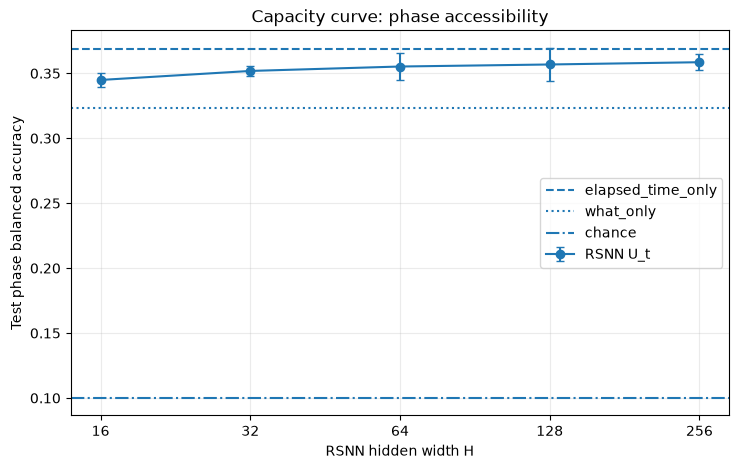

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.errorbar(capacity["hidden_width"], capacity["phase_ba_mean"], yerr=capacity["phase_ba_sd"], marker="o", capsize=3, label="RSNN U_t")
ax.axhline(elapsed_phase, linestyle="--", label="elapsed_time_only")
ax.axhline(what_phase, linestyle=":", label="what_only")
ax.axhline(0.10, linestyle="-.", label="chance")
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Test phase balanced accuracy")
ax.set_title("Capacity curve: phase accessibility")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


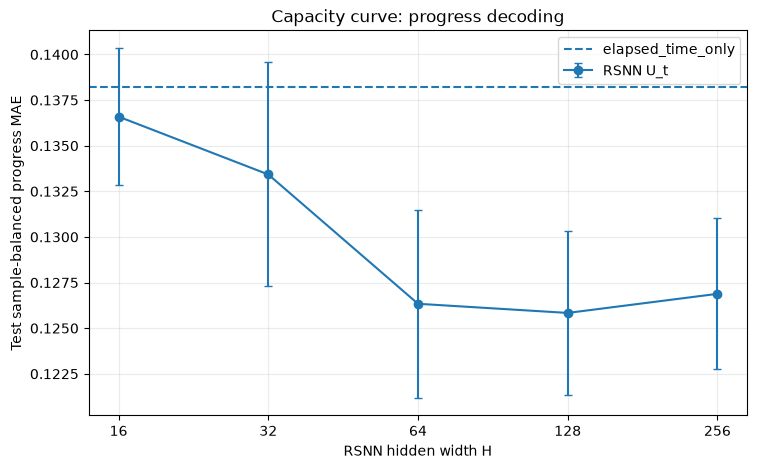

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.errorbar(capacity["hidden_width"], capacity["progress_mae_mean"], yerr=capacity["progress_mae_sd"], marker="o", capsize=3, label="RSNN U_t")
ax.axhline(elapsed_mae, linestyle="--", label="elapsed_time_only")
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Test sample-balanced progress MAE")
ax.set_title("Capacity curve: progress decoding")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 2. Generalization

Common `U_t` probe train/val/test curves expose underfitting, plateauing, or overcapacity without mixing training-head capacity across widths.


In [6]:
generalization = runs.groupby("hidden_width", as_index=False).agg(
    train_phase=("probe_u_train_phase_ba", "mean"),
    val_phase=("probe_u_val_phase_ba", "mean"),
    test_phase=("probe_u_test_phase_ba", "mean"),
    train_mae=("probe_train_sample_balanced_mae_mean", "mean"),
    val_mae=("probe_val_sample_balanced_mae_mean", "mean"),
    test_mae=("probe_test_sample_balanced_mae_mean", "mean"),
    phase_gap=("probe_phase_train_val_gap", "mean"),
    progress_gap=("probe_progress_val_train_gap", "mean"),
)
generalization


,hidden_width,train_phase,val_phase,test_phase,train_mae,val_mae,test_mae,phase_gap,progress_gap
0,16,0.420776,0.336247,0.344885,0.134895,0.144033,0.136593,0.084529,0.009138
1,32,0.448748,0.340142,0.351826,0.117814,0.135004,0.133423,0.108606,0.017190
2,64,0.471255,0.345050,0.355236,0.107984,0.130289,0.126337,0.126205,0.022305
3,128,0.503987,0.351150,0.356806,0.101404,0.127631,0.125835,0.152837,0.026227
4,256,0.541885,0.359770,0.358549,0.097556,0.125606,0.126881,0.182115,0.028051


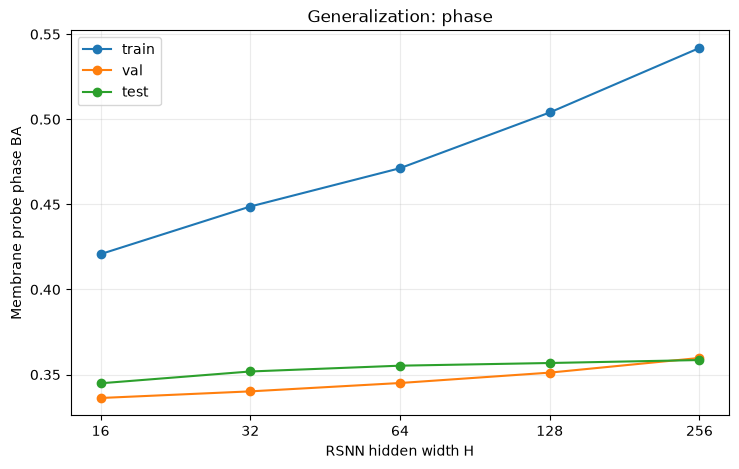

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for column, label in (("train_phase", "train"), ("val_phase", "val"), ("test_phase", "test")):
    ax.plot(generalization["hidden_width"], generalization[column], marker="o", label=label)
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Membrane probe phase BA")
ax.set_title("Generalization: phase")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


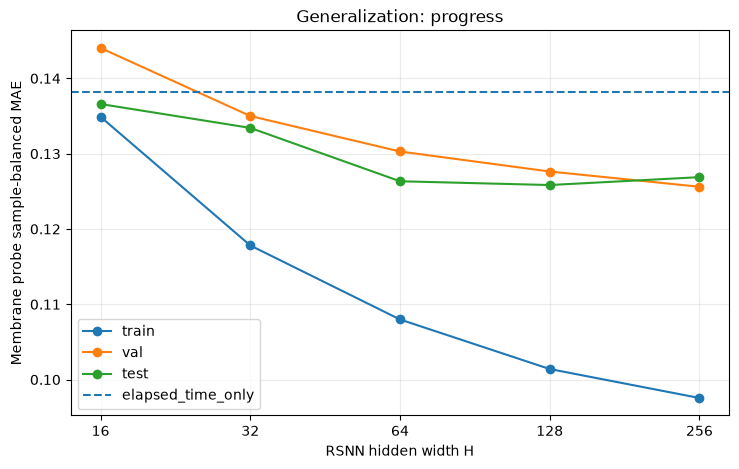

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for column, label in (("train_mae", "train"), ("val_mae", "val"), ("test_mae", "test")):
    ax.plot(generalization["hidden_width"], generalization[column], marker="o", label=label)
ax.axhline(elapsed_mae, linestyle="--", label="elapsed_time_only")
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Membrane probe sample-balanced MAE")
ax.set_title("Generalization: progress")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 3. Temporal quality

Spearman measures whether decoded progress moves forward overall; monotonic violation measures local backward steps.


In [9]:
temporal_quality = runs.groupby("hidden_width", as_index=False).agg(
    spearman_mean=("probe_test_spearman_mean", "mean"),
    spearman_sd=("probe_test_spearman_mean", "std"),
    violation_mean=("probe_test_monotonic_violation_rate_mean", "mean"),
    violation_sd=("probe_test_monotonic_violation_rate_mean", "std"),
)
temporal_quality


,hidden_width,spearman_mean,spearman_sd,violation_mean,violation_sd
0,16,0.893963,0.014099,0.327869,0.006714
1,32,0.912133,0.013659,0.318330,0.013765
2,64,0.931670,0.013851,0.296387,0.007558
3,128,0.934158,0.006276,0.300378,0.005434
4,256,0.928046,0.011683,0.308579,0.005742


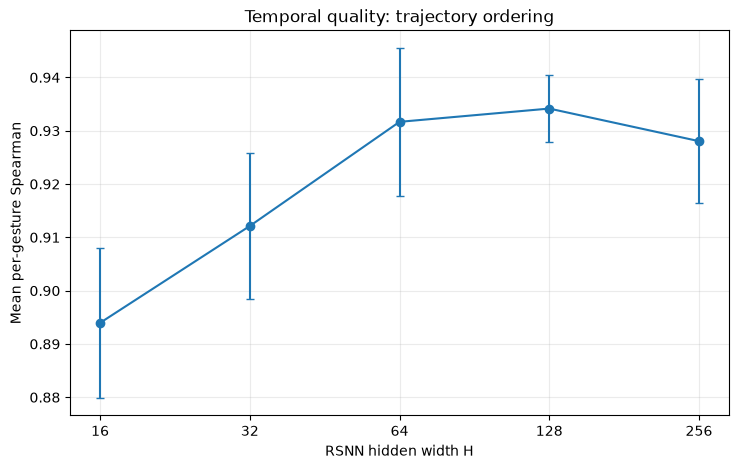

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.errorbar(temporal_quality["hidden_width"], temporal_quality["spearman_mean"], yerr=temporal_quality["spearman_sd"], marker="o", capsize=3)
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Mean per-gesture Spearman")
ax.set_title("Temporal quality: trajectory ordering")
ax.grid(alpha=0.25)
plt.show()


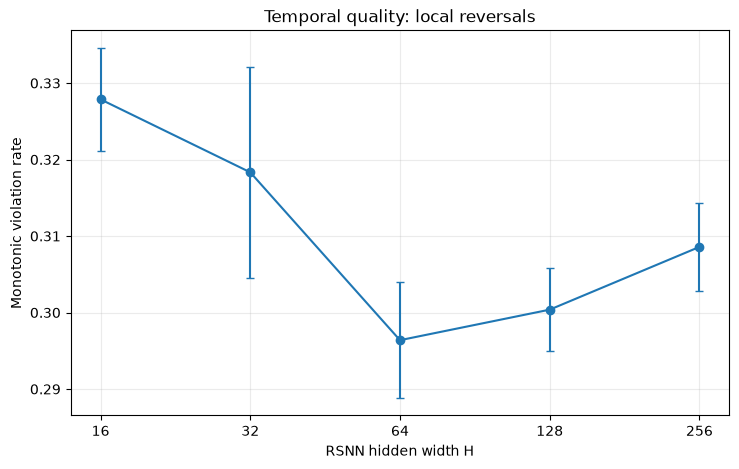

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.errorbar(temporal_quality["hidden_width"], temporal_quality["violation_mean"], yerr=temporal_quality["violation_sd"], marker="o", capsize=3)
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Monotonic violation rate")
ax.set_title("Temporal quality: local reversals")
ax.grid(alpha=0.25)
plt.show()


## 4. History contribution

`H_reset` and `H_shuffle` quantify how much linearly accessible WHEN information depends on carried state and ordered history.


In [12]:
history_summary = history_gain_runs.groupby("hidden_width", as_index=False).agg(
    H_reset_phase=("H_reset_phase_ba", "mean"),
    H_shuffle_phase=("H_shuffle_phase_ba", "mean"),
    H_reset_progress=("H_reset_progress_mae", "mean"),
    H_shuffle_progress=("H_shuffle_progress_mae", "mean"),
)
history_summary


,hidden_width,H_reset_phase,H_shuffle_phase,H_reset_progress,H_shuffle_progress
0,16,0.044038,0.175881,0.021439,0.099170
1,32,0.047262,0.156618,0.026048,0.084636
2,64,0.047235,0.112571,0.025927,0.059235
3,128,0.039449,0.103138,0.019712,0.053459
4,256,0.035739,0.102569,0.015571,0.054338


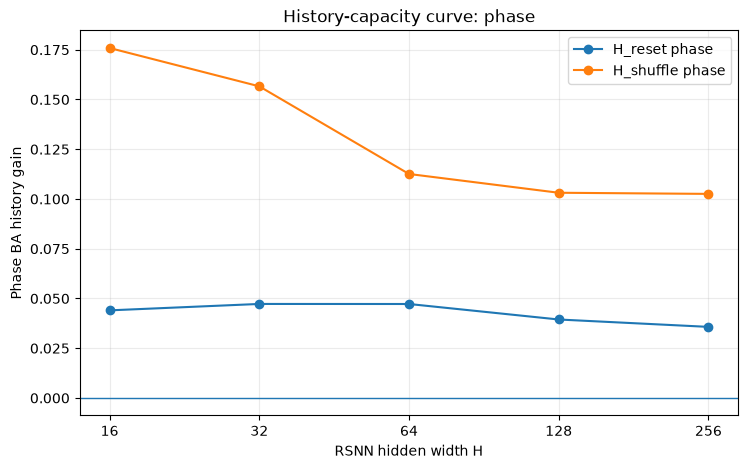

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(history_summary["hidden_width"], history_summary["H_reset_phase"], marker="o", label="H_reset phase")
ax.plot(history_summary["hidden_width"], history_summary["H_shuffle_phase"], marker="o", label="H_shuffle phase")
ax.axhline(0.0, linewidth=1)
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Phase BA history gain")
ax.set_title("History-capacity curve: phase")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


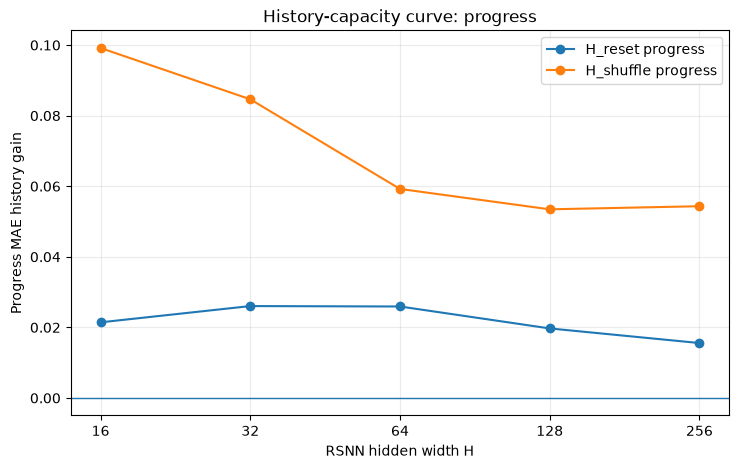

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(history_summary["hidden_width"], history_summary["H_reset_progress"], marker="o", label="H_reset progress")
ax.plot(history_summary["hidden_width"], history_summary["H_shuffle_progress"], marker="o", label="H_shuffle progress")
ax.axhline(0.0, linewidth=1)
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Progress MAE history gain")
ax.set_title("History-capacity curve: progress")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 5. SNN-native accessibility

Compare membrane, synaptic current/state, instantaneous spikes, trailing 250 ms spike counts, and trailing 500 ms spike counts with the same post-hoc probe protocol.


In [15]:
feature_order = ["membrane", "synaptic", "spike", "spike250", "spike500"]
accessibility = probe_runs.groupby(["hidden_width", "feature_type"], as_index=False).agg(
    phase_ba=("phase_probe_test_ba", "mean"),
    progress_mae=("progress_probe_test_sample_balanced_mae_mean", "mean"),
)
accessibility


,hidden_width,feature_type,phase_ba,progress_mae
0,16,membrane,0.344885,0.136593
1,16,spike,0.304258,0.139317
2,16,spike250,0.311486,0.130014
3,16,spike500,0.314280,0.126998
4,16,synaptic,0.343672,0.136966
5,32,membrane,0.351826,0.133423
6,32,spike,0.323275,0.133538
7,32,spike250,0.326960,0.127463
8,32,spike500,0.318640,0.126789
9,32,synaptic,0.352778,0.134917


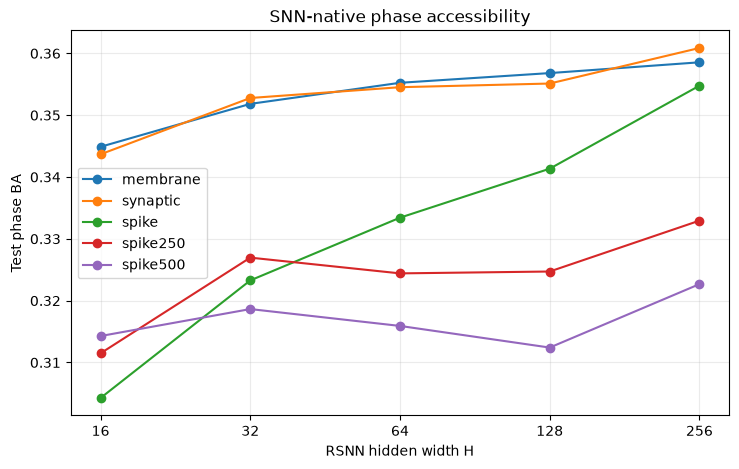

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for feature in feature_order:
    part = accessibility[accessibility["feature_type"].eq(feature)]
    ax.plot(part["hidden_width"], part["phase_ba"], marker="o", label=feature)
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Test phase BA")
ax.set_title("SNN-native phase accessibility")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


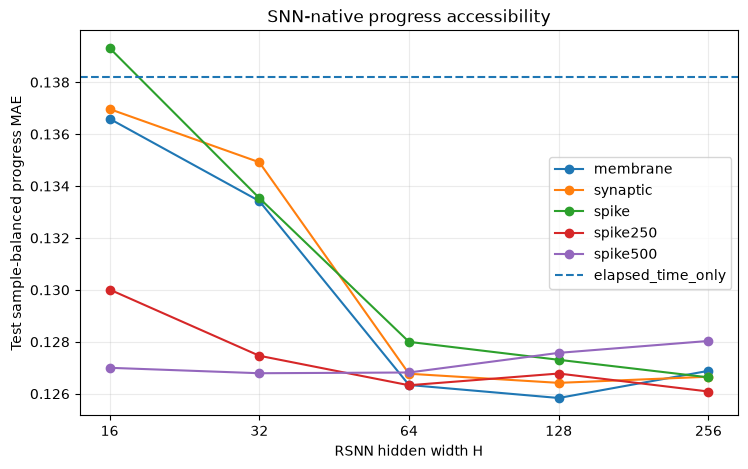

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for feature in feature_order:
    part = accessibility[accessibility["feature_type"].eq(feature)]
    ax.plot(part["hidden_width"], part["progress_mae"], marker="o", label=feature)
ax.axhline(elapsed_mae, linestyle="--", label="elapsed_time_only")
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Test sample-balanced progress MAE")
ax.set_title("SNN-native progress accessibility")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 6. Activity utilization

A larger nominal state may be unused if many neurons are dead or if firing collapses into a different regime.


In [18]:
activity_summary = activity_runs.groupby("hidden_width", as_index=False).agg(
    mean_fr=("mean_firing_rate", "mean"),
    median_neuron_fr=("median_neuron_firing_rate", "mean"),
    dead_fraction=("dead_neuron_fraction", "mean"),
    highly_active_fraction=("highly_active_neuron_fraction", "mean"),
)
activity_summary


,hidden_width,mean_fr,median_neuron_fr,dead_fraction,highly_active_fraction
0,16,0.393219,0.386887,0.0,0.787500
1,32,0.306761,0.244831,0.0,0.731250
2,64,0.350433,0.336150,0.0,0.800000
3,128,0.291323,0.261788,0.0,0.851562
4,256,0.269954,0.253554,0.0,0.880469


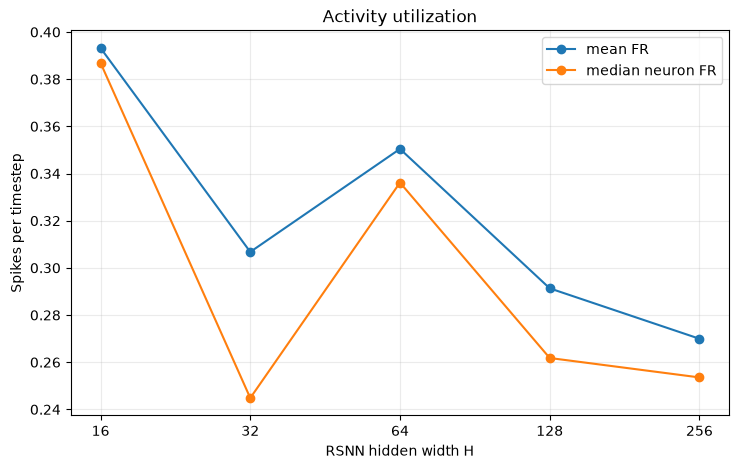

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(activity_summary["hidden_width"], activity_summary["mean_fr"], marker="o", label="mean FR")
ax.plot(activity_summary["hidden_width"], activity_summary["median_neuron_fr"], marker="o", label="median neuron FR")
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Spikes per timestep")
ax.set_title("Activity utilization")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


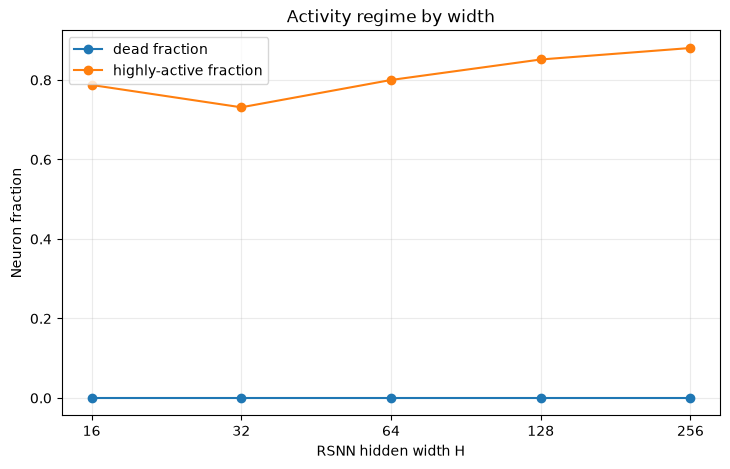

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(activity_summary["hidden_width"], activity_summary["dead_fraction"], marker="o", label="dead fraction")
ax.plot(activity_summary["hidden_width"], activity_summary["highly_active_fraction"], marker="o", label="highly-active fraction")
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Neuron fraction")
ax.set_title("Activity regime by width")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 7. Effective state dimension

`effective_dimension` is the participation ratio of the test membrane covariance spectrum; `pca90_dimension` is the number of leading PCs required for at least 90% variance.


In [21]:
dimension_summary = representation_runs.groupby("hidden_width", as_index=False).agg(
    effective_dimension=("effective_dimension", "mean"),
    pca90_dimension=("pca90_dimension", "mean"),
    total_variance=("total_variance", "mean"),
)
dimension_summary


,hidden_width,effective_dimension,pca90_dimension,total_variance
0,16,2.825267,6.0,44.393595
1,32,3.441049,9.4,74.384367
2,64,4.239438,15.4,107.387183
3,128,5.708165,28.8,175.583076
4,256,9.226984,59.4,263.920488


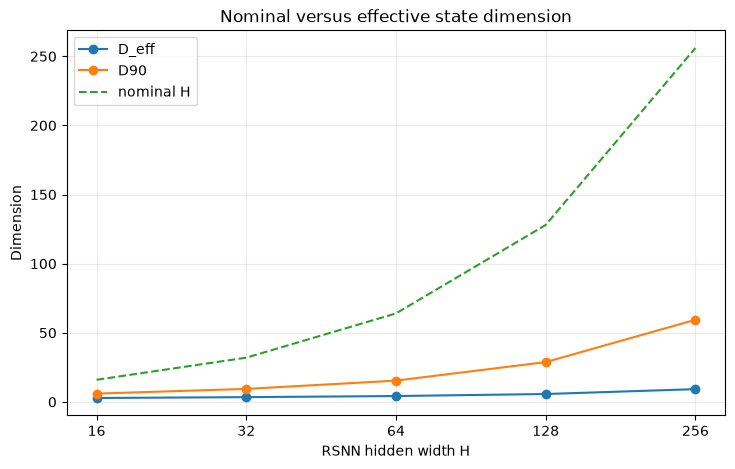

In [22]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(dimension_summary["hidden_width"], dimension_summary["effective_dimension"], marker="o", label="D_eff")
ax.plot(dimension_summary["hidden_width"], dimension_summary["pca90_dimension"], marker="o", label="D90")
ax.plot(dimension_summary["hidden_width"], dimension_summary["hidden_width"], linestyle="--", label="nominal H")
ax.set_xscale("log", base=2)
ax.set_xticks([16, 32, 64, 128, 256], labels=[16, 32, 64, 128, 256])
ax.set_xlabel("RSNN hidden width H")
ax.set_ylabel("Dimension")
ax.set_title("Nominal versus effective state dimension")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 8. Hierarchical winner selection

Eligibility first requires mean progress MAE below the elapsed-time baseline and positive mean ordered-history gains. Eligible widths are then inspected by phase BA, progress MAE, history gain, parameter count, and spike accessibility. No single composite score is used.


In [23]:
winner = capacity.merge(history_summary, on="hidden_width").merge(
    activity_summary[["hidden_width", "dead_fraction"]], on="hidden_width"
).merge(
    dimension_summary[["hidden_width", "effective_dimension", "pca90_dimension"]], on="hidden_width"
)
winner["beats_elapsed_progress"] = winner["progress_mae_mean"] < elapsed_mae
winner["uses_ordered_history"] = (
    (winner["H_reset_phase"] > 0.0)
    & (winner["H_shuffle_phase"] > 0.0)
    & (winner["H_reset_progress"] > 0.0)
    & (winner["H_shuffle_progress"] > 0.0)
)
winner["eligible"] = winner["beats_elapsed_progress"] & winner["uses_ordered_history"]
winner = winner.sort_values(
    ["eligible", "phase_ba_mean", "progress_mae_mean", "parameter_count"],
    ascending=[False, False, True, True],
)
winner[[
    "hidden_width", "parameter_count", "phase_ba_mean", "progress_mae_mean",
    "H_reset_phase", "H_shuffle_phase", "H_reset_progress", "H_shuffle_progress",
    "dead_fraction", "effective_dimension", "pca90_dimension", "eligible"
]]


,hidden_width,parameter_count,phase_ba_mean,progress_mae_mean,H_reset_phase,H_shuffle_phase,H_reset_progress,H_shuffle_progress,dead_fraction,effective_dimension,pca90_dimension,eligible
4,256,101131.0,0.358549,0.126881,0.035739,0.102569,0.015571,0.054338,0.0,9.226984,59.4,True
3,128,34187.0,0.356806,0.125835,0.039449,0.103138,0.019712,0.053459,0.0,5.708165,28.8,True
2,64,13003.0,0.355236,0.126337,0.047235,0.112571,0.025927,0.059235,0.0,4.239438,15.4,True
1,32,5483.0,0.351826,0.133423,0.047262,0.156618,0.026048,0.084636,0.0,3.441049,9.4,True
0,16,2491.0,0.344885,0.136593,0.044038,0.175881,0.021439,0.099170,0.0,2.825267,6.0,True


### Interpretation

- If H256 continues to improve absolute WHEN quality and ordered-history gain, capacity still matters.
- If a smaller width peaks while train fit keeps improving at H128/H256, prefer the smaller generalizing RSNN.
- If H16–H256 plateau and `D_eff`/`D90` saturate, the single-layer recurrent transformation is the likely bottleneck; the next test should be `WHAT_128 -> FF-SNN -> RSNN`, not an automatic H512 sweep.
